# Calculadora de Salario Real — Ajuste por Inflación IPC Colombia

**Fuente:** DANE – IPC Nacional | Ministerio del Trabajo – SMMLV  
**Período base:** 2010 – 2024

---

## ¿Qué es el salario real?

El **salario nominal** es el número de pesos que aparece en tu nómina.  
El **salario real** es lo que realmente puedes comprar con ese salario.

> Si tu salario pasó de $1.000.000 en 2015 a $2.000.000 en 2024,  
> ¿subiste de verdad? Depende: si los precios también se duplicaron, tu poder adquisitivo es el mismo.

Este notebook responde tres preguntas prácticas para cualquier colombiano:

1. ¿Cuánto equivale hoy (2024) un salario del pasado en términos de poder de compra?
2. ¿Cuántos SMMLV (salarios mínimos) representa ese salario?
3. ¿Subió o bajó tu salario en términos reales entre dos años?

---

### Instrucciones de uso

Cambia los valores en la sección **"PARÁMETROS DEL USUARIO"** con tu información:
- `MI_SALARIO_ORIGINAL`: tu salario en el año de referencia
- `MI_AÑO_ORIGEN`: el año en que recibías ese salario  
- `MI_SALARIO_ACTUAL`: tu salario hoy (o en el año destino)
- `MI_AÑO_DESTINO`: el año al que quieres comparar (normalmente 2024)


In [1]:
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from pathlib import Path

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('..') / 'src'))
from colombia_data.ipc import get_ipc

plt.rcParams.update({
    'figure.dpi': 130, 'font.family': 'DejaVu Sans',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--',
    'axes.labelsize': 11, 'xtick.labelsize': 9, 'ytick.labelsize': 9,
})
RUTA_OUT = Path('..') / 'assets' / 'visualizaciones'
RUTA_OUT.mkdir(parents=True, exist_ok=True)

# ── Cargar IPC ────────────────────────────────────────────────────────────
df_ipc = get_ipc(anio_inicio=2010, anio_fin=2024)

# Factor de ajuste acumulado por año (IPC diciembre de cada año)
ipc_dic = df_ipc[df_ipc['mes'] == 12].set_index('año')['ipc']

# SMMLV histórico (Ministerio del Trabajo)
smmlv = pd.Series({
    2010: 515_000,  2011: 535_600,  2012: 566_700,  2013: 589_500,
    2014: 616_000,  2015: 644_350,  2016: 689_455,  2017: 737_717,
    2018: 781_242,  2019: 828_116,  2020: 877_803,  2021: 908_526,
    2022: 1_000_000, 2023: 1_160_000, 2024: 1_300_000,
}, name='smmlv_cop')

print("IPC disponible:")
print(ipc_dic.to_frame('ipc_dic').T.to_string())
print()
print("SMMLV histórico (pesos nominales):")
for año, val in smmlv.items():
    print(f"  {año}: ${val:>12,.0f}")


IPC disponible:
año        2010    2011    2012    2013    2014    2015    2016    2017    2018    2019    2020    2021    2022    2023    2024
ipc_dic  187.89  195.02  199.83  203.74  211.33  226.08  239.43  249.41  257.46  267.41  271.75  287.42  327.48  359.19  378.32

SMMLV histórico (pesos nominales):
  2010: $     515,000
  2011: $     535,600
  2012: $     566,700
  2013: $     589,500
  2014: $     616,000
  2015: $     644,350
  2016: $     689,455
  2017: $     737,717
  2018: $     781,242
  2019: $     828,116
  2020: $     877,803
  2021: $     908,526
  2022: $   1,000,000
  2023: $   1,160,000
  2024: $   1,300,000


## Función de ajuste por inflación

Implementamos la lógica de ajuste directamente con el índice IPC, sin depender de librerías externas.

In [2]:
def ajustar_por_inflacion(valor, año_origen, año_destino, ipc_serie=ipc_dic):
    """
    Ajusta un valor monetario por inflación entre dos años usando el IPC de diciembre.
    
    Parámetros
    ----------
    valor : float
        Monto en pesos del año de origen.
    año_origen : int
        Año en que está expresado el valor.
    año_destino : int
        Año al que se quiere expresar el valor.
    ipc_serie : pd.Series
        Serie de IPC indexada por año.
    
    Retorna
    -------
    float
        Valor en pesos del año destino con el mismo poder adquisitivo.
    
    Ejemplo
    -------
    >>> valor_hoy = ajustar_por_inflacion(1_000_000, 2015, 2024)
    >>> print(f"$1.000.000 de 2015 equivalen a ${valor_hoy:,.0f} en 2024")
    """
    if año_origen == año_destino:
        return float(valor)
    ipc_o = ipc_serie.loc[año_origen]
    ipc_d = ipc_serie.loc[año_destino]
    return round(float(valor) * (ipc_d / ipc_o), 2)


def smmlv_equivalente(valor, año, smmlv_serie=smmlv):
    """Calcula cuántos SMMLV equivale un valor en un año dado."""
    return round(valor / smmlv_serie.loc[año], 2)


# ── Verificación ─────────────────────────────────────────────────────────
ej = ajustar_por_inflacion(1_000_000, 2015, 2024)
print(f"Ejemplo: $1.000.000 en 2015 equivalen a ${ej:,.0f} en 2024")
print(f"         (el peso perdio el {(1 - 1_000_000/ej)*100:.1f}% de su valor en ese periodo)")
print()
smmlv_en_2015 = smmlv_equivalente(1_000_000, 2015)
print(f"$1.000.000 en 2015 = {smmlv_en_2015:.2f} SMMLV de ese año")
print(f"$1.000.000 en 2024 = {smmlv_equivalente(1_000_000, 2024):.2f} SMMLV de este año")


Ejemplo: $1.000.000 en 2015 equivalen a $1,673,390 en 2024
         (el peso perdio el 40.2% de su valor en ese periodo)

$1.000.000 en 2015 = 1.55 SMMLV de ese año
$1.000.000 en 2024 = 0.77 SMMLV de este año


## Calculadora Personal

Modifica los parámetros a continuación con tu propio salario para obtener tu análisis personalizado.


In [3]:
# ════════════════════════════════════════════════════════════════
#   PARÁMETROS DEL USUARIO — modifica estos valores
# ════════════════════════════════════════════════════════════════
MI_SALARIO_ORIGEN  = 1_500_000   # Tu salario en el año de referencia
MI_AÑO_ORIGEN      = 2018        # Año de referencia
MI_SALARIO_ACTUAL  = 3_200_000   # Tu salario actual (o del año destino)
MI_AÑO_DESTINO     = 2024        # Año actual o de comparación
# ════════════════════════════════════════════════════════════════

# Cálculos
salario_ajustado = ajustar_por_inflacion(MI_SALARIO_ORIGEN, MI_AÑO_ORIGEN, MI_AÑO_DESTINO)
variacion_nominal = (MI_SALARIO_ACTUAL / MI_SALARIO_ORIGEN - 1) * 100
variacion_real    = (MI_SALARIO_ACTUAL / salario_ajustado  - 1) * 100

smmlv_origen  = smmlv_equivalente(MI_SALARIO_ORIGEN,  MI_AÑO_ORIGEN)
smmlv_destino = smmlv_equivalente(MI_SALARIO_ACTUAL,  MI_AÑO_DESTINO)

print("=" * 55)
print("  ANÁLISIS DE SALARIO REAL")
print("=" * 55)
print(f"  Salario en {MI_AÑO_ORIGEN}           : ${MI_SALARIO_ORIGEN:>12,.0f}")
print(f"  Equivalente en {MI_AÑO_DESTINO} (IPC) : ${salario_ajustado:>12,.0f}")
print(f"  Tu salario en {MI_AÑO_DESTINO}         : ${MI_SALARIO_ACTUAL:>12,.0f}")
print("-" * 55)
print(f"  Variación nominal ({MI_AÑO_ORIGEN}→{MI_AÑO_DESTINO}): {variacion_nominal:+.1f}%")
print(f"  Variación real    ({MI_AÑO_ORIGEN}→{MI_AÑO_DESTINO}): {variacion_real:+.1f}%")
print("-" * 55)
print(f"  SMMLV en {MI_AÑO_ORIGEN}  : {smmlv_origen:.2f} salarios mínimos")
print(f"  SMMLV en {MI_AÑO_DESTINO}  : {smmlv_destino:.2f} salarios mínimos")
print("=" * 55)

if variacion_real > 0:
    print(f"\n  RESULTADO: tu salario GANÓ {variacion_real:.1f}% en términos reales.")
    print(f"  Tienes {variacion_real:.1f}% más poder adquisitivo que en {MI_AÑO_ORIGEN}.")
else:
    print(f"\n  RESULTADO: tu salario PERDIÓ {abs(variacion_real):.1f}% en términos reales.")
    print(f"  Necesitarías ${salario_ajustado:,.0f} solo para mantener tu nivel de vida de {MI_AÑO_ORIGEN}.")


  ANÁLISIS DE SALARIO REAL
  Salario en 2018           : $   1,500,000
  Equivalente en 2024 (IPC) : $   2,204,148
  Tu salario en 2024         : $   3,200,000
-------------------------------------------------------
  Variación nominal (2018→2024): +113.3%
  Variación real    (2018→2024): +45.2%
-------------------------------------------------------
  SMMLV en 2018  : 1.92 salarios mínimos
  SMMLV en 2024  : 2.46 salarios mínimos

  RESULTADO: tu salario GANÓ 45.2% en términos reales.
  Tienes 45.2% más poder adquisitivo que en 2018.


## 1. Evolución del Poder Adquisitivo del SMMLV (2010–2024)

El salario mínimo sube cada año, pero ¿cuánto de ese aumento es real? Veamos cuántos pesos de 2024 equivale el mínimo de cada año.

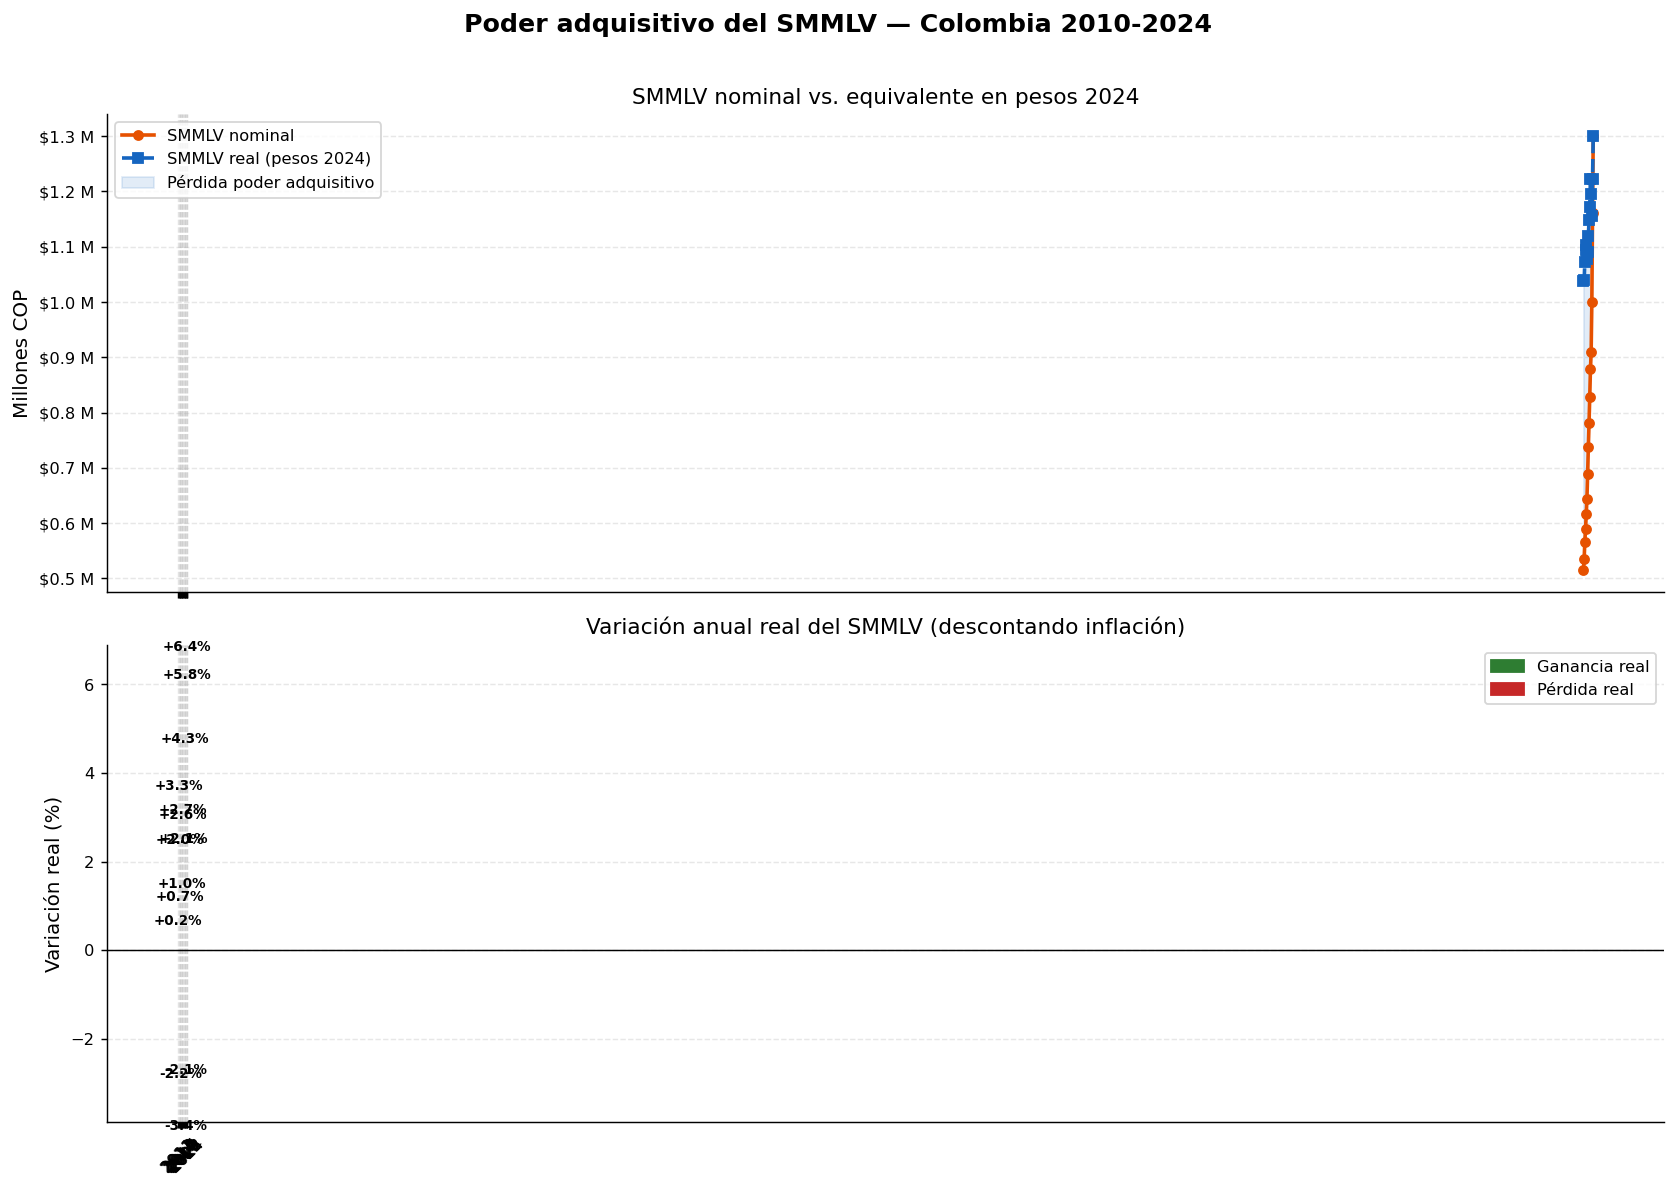

Guardada: salario_real_smmlv_historico.png

SMMlv 2010 nominal:   $     515,000
SMMLV 2024 nominal:   $   1,300,000  (+152.4% nominal)
SMMLV 2010 en pesos 2024: $   1,036,962
Variación real 2010-2024: +25.4%


In [4]:
# SMMLV nominal vs real (en pesos 2024)
smmlv_real_2024 = pd.Series({
    año: ajustar_por_inflacion(val, año, 2024)
    for año, val in smmlv.items()
}, name='smmlv_real_2024')

años = smmlv.index.tolist()

fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
fig.suptitle('Poder adquisitivo del SMMLV — Colombia 2010-2024',
             fontsize=14, fontweight='bold', y=1.01)

# Panel 1: nominal vs real
ax1 = axes[0]
ax2 = axes[1]
ax1.plot(años, smmlv.values / 1e6, marker='o', markersize=5,
         linewidth=2, color='#E65100', label='SMMLV nominal')
ax1.plot(años, smmlv_real_2024.values / 1e6, marker='s', markersize=5,
         linewidth=2, linestyle='--', color='#1565C0',
         label='SMMLV real (pesos 2024)')
ax1.fill_between(años, smmlv.values / 1e6, smmlv_real_2024.values / 1e6,
                 where=[r > n for r, n in zip(smmlv_real_2024.values, smmlv.values)],
                 alpha=0.12, color='#1565C0', label='Pérdida poder adquisitivo')
ax1.set_ylabel('Millones COP')
ax1.set_title('SMMLV nominal vs. equivalente en pesos 2024')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f} M'))
ax1.legend(fontsize=9)

# Panel 2: variación real del SMMLV año a año
var_real = smmlv_real_2024.pct_change() * 100
colors2  = ['#2E7D32' if v > 0 else '#C62828' for v in var_real.dropna()]
ax2.bar([str(a) for a in años[1:]], var_real.dropna().values,
        color=colors2, width=0.65, edgecolor='white')
ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_title('Variación anual real del SMMLV (descontando inflación)')
ax2.set_ylabel('Variación real (%)')
ax2.tick_params(axis='x', rotation=45)
for i, (año, val) in enumerate(zip(años[1:], var_real.dropna())):
    offset = 0.3 if val >= 0 else -0.4
    va = 'bottom' if val >= 0 else 'top'
    ax2.text(i, val + offset, f'{val:+.1f}%',
             ha='center', va=va, fontsize=7.5, fontweight='bold')

p_g = mpatches.Patch(color='#2E7D32', label='Ganancia real')
p_p = mpatches.Patch(color='#C62828', label='Pérdida real')
ax2.legend(handles=[p_g, p_p], fontsize=9)

plt.tight_layout()
fig.savefig(RUTA_OUT / 'salario_real_smmlv_historico.png', dpi=130, bbox_inches='tight')
plt.show()
print("Guardada: salario_real_smmlv_historico.png")

total_real = ((smmlv_real_2024.iloc[-1] / smmlv_real_2024.iloc[0]) - 1) * 100
total_nom  = ((smmlv.iloc[-1]          / smmlv.iloc[0])           - 1) * 100
print(f"\nSMMlv 2010 nominal:   ${smmlv.iloc[0]:>12,.0f}")
print(f"SMMLV 2024 nominal:   ${smmlv.iloc[-1]:>12,.0f}  (+{total_nom:.1f}% nominal)")
print(f"SMMLV 2010 en pesos 2024: ${smmlv_real_2024.iloc[0]:>12,.0f}")
print(f"Variación real 2010-2024: {total_real:+.1f}%")


In [5]:
# El panel 2 no se creó correctamente arriba - necesitamos el objeto ax2
# Este bloque está integrado en el anterior; aquí lo dejamos vacío.
pass


## 2. Tabla de Equivalencias: Tu Salario en Distintos Años

Esta tabla muestra cuántos pesos de 2024 equivale cada nivel de salario en años pasados.

In [6]:
salarios_ejemplo = [800_000, 1_000_000, 1_500_000, 2_000_000,
                    3_000_000, 5_000_000, 8_000_000, 12_000_000]
años_tabla = [2010, 2012, 2015, 2018, 2020, 2022, 2023, 2024]

tabla = {}
for sal in salarios_ejemplo:
    fila = {}
    for año in años_tabla:
        if año == 2024:
            fila[str(año)] = f'${sal:>12,.0f}'
        else:
            equiv = ajustar_por_inflacion(sal, año, 2024)
            fila[str(año)] = f'${equiv:>12,.0f}'
    tabla[f'${sal:,.0f}'] = fila

df_tabla = pd.DataFrame(tabla).T
df_tabla.index.name = 'Salario original'
print("Equivalencia en pesos de 2024 de distintos salarios históricos:")
print("(¿cuántos pesos de 2024 necesitas para tener el mismo poder que X pesos en año Y?)")
print()
print(df_tabla.to_string())


Equivalencia en pesos de 2024 de distintos salarios históricos:
(¿cuántos pesos de 2024 necesitas para tener el mismo poder que X pesos en año Y?)

                           2010           2012           2015           2018           2020           2022           2023           2024
Salario original                                                                                                                        
$800,000          $   1,610,815  $   1,514,567  $   1,338,712  $   1,175,546  $   1,113,730  $     924,197  $     842,607  $     800,000
$1,000,000        $   2,013,519  $   1,893,209  $   1,673,390  $   1,469,432  $   1,392,162  $   1,155,246  $   1,053,259  $   1,000,000
$1,500,000        $   3,020,278  $   2,839,814  $   2,510,085  $   2,204,148  $   2,088,243  $   1,732,869  $   1,579,888  $   1,500,000
$2,000,000        $   4,027,037  $   3,786,418  $   3,346,780  $   2,938,864  $   2,784,324  $   2,310,492  $   2,106,517  $   2,000,000
$3,000,000        $   6,040,55

## 3. Índice de Erosión Salarial 2010–2024

Si hubiera mantenido siempre el mismo salario nominal (sin aumentos), ¿cuánto habría perdido en términos reales cada año?

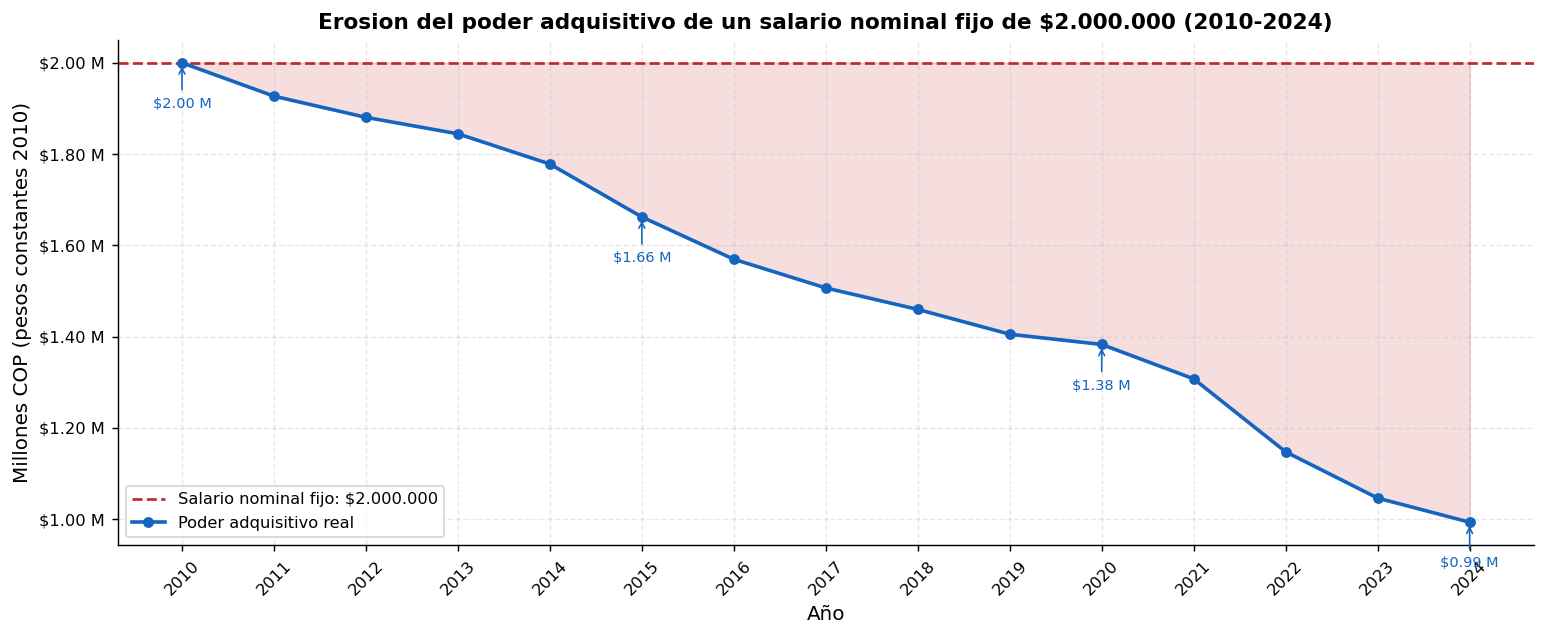

Guardada: salario_real_erosion_nominal.png

Un salario de $2.000.000 congelado desde 2010 equivale hoy a $993,286
Perdida de poder adquisitivo 2010-2024: -50.3%
(El peso te 'quitó' $1,006,714 en terminos reales)


In [7]:
salario_fijo = 2_000_000   # salario nominal congelado desde 2010

poder_real = pd.Series({
    año: salario_fijo / (ipc_dic.loc[año] / ipc_dic.loc[2010])
    for año in años
}, name='poder_adquisitivo')

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(años, poder_real.values / 1e6, salario_fijo / 1e6,
                alpha=0.15, color='#C62828')
ax.axhline(salario_fijo / 1e6, color='#C62828', linewidth=1.5,
           linestyle='--', label=f'Salario nominal fijo: $2.000.000')
ax.plot(años, poder_real.values / 1e6, color='#1565C0', marker='o',
        markersize=5, linewidth=2, label='Poder adquisitivo real')

for año, val in zip(años, poder_real.values):
    if año in [2010, 2015, 2020, 2024]:
        ax.annotate(f'${val/1e6:.2f} M',
                    xy=(año, val/1e6), xytext=(0, -25),
                    textcoords='offset points', ha='center', fontsize=8,
                    color='#1565C0',
                    arrowprops=dict(arrowstyle='->', color='#1565C0', lw=0.9))

ax.set_title('Erosion del poder adquisitivo de un salario nominal fijo de $2.000.000 (2010-2024)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Millones COP (pesos constantes 2010)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.2f} M'))
ax.set_xticks(años)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(RUTA_OUT / 'salario_real_erosion_nominal.png', dpi=130, bbox_inches='tight')
plt.show()
print("Guardada: salario_real_erosion_nominal.png")

perdida = ((poder_real.iloc[-1] / poder_real.iloc[0]) - 1) * 100
print(f"\nUn salario de $2.000.000 congelado desde 2010 equivale hoy a ${poder_real.iloc[-1]:,.0f}")
print(f"Perdida de poder adquisitivo 2010-2024: {perdida:.1f}%")
print(f"(El peso te 'quitó' ${(salario_fijo - poder_real.iloc[-1]):,.0f} en terminos reales)")


## 4. ¿Cuántos SMMLV es tu Salario? Evolución Histórica

El SMMLV es la unidad de medida más usada en Colombia para comparar salarios. Aquí vemos cómo ha cambiado el poder de 1, 2, 3 y 5 SMMLV en pesos constantes de 2024.

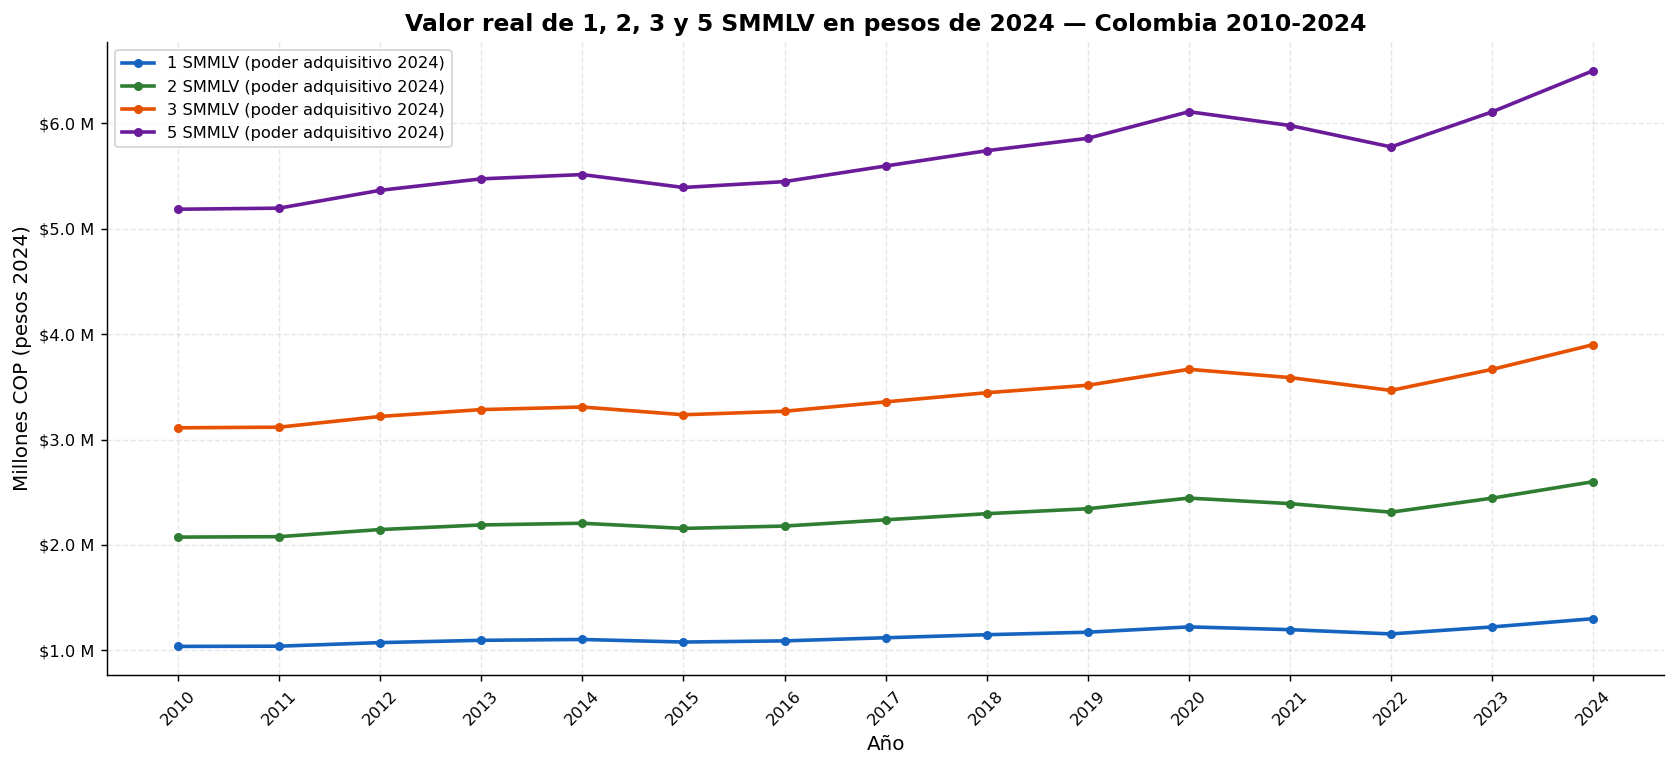

Guardada: salario_real_multiplos_smmlv.png

Poder real de 1 SMMLV en pesos de 2024:
  2010: $ 1,036,962  (0.80 SMMLV 2024)
  2011: $ 1,039,012  (0.80 SMMLV 2024)
  2012: $ 1,072,882  (0.83 SMMLV 2024)
  2013: $ 1,094,629  (0.84 SMMLV 2024)
  2014: $ 1,102,755  (0.85 SMMLV 2024)
  2015: $ 1,078,249  (0.83 SMMLV 2024)
  2016: $ 1,089,398  (0.84 SMMLV 2024)
  2017: $ 1,119,013  (0.86 SMMLV 2024)
  2018: $ 1,147,982  (0.88 SMMLV 2024)
  2019: $ 1,171,582  (0.90 SMMLV 2024)
  2020: $ 1,222,044  (0.94 SMMLV 2024)
  2021: $ 1,195,858  (0.92 SMMLV 2024)
  2022: $ 1,155,246  (0.89 SMMLV 2024)
  2023: $ 1,221,780  (0.94 SMMLV 2024)
  2024: $ 1,300,000  (1.00 SMMLV 2024)


In [8]:
multiplos = [1, 2, 3, 5]

fig, ax = plt.subplots(figsize=(13, 6))
colores_mult = ['#1565C0', '#2E7D32', '#E65100', '#6A1B9A']

for mult, color in zip(multiplos, colores_mult):
    vals_nominales = (smmlv * mult).values
    vals_reales    = [ajustar_por_inflacion(v, a, 2024)
                      for v, a in zip(vals_nominales, años)]
    ax.plot(años, [v/1e6 for v in vals_reales],
            marker='o', markersize=4, linewidth=2,
            label=f'{mult} SMMLV (poder adquisitivo 2024)', color=color)

ax.set_title('Valor real de 1, 2, 3 y 5 SMMLV en pesos de 2024 — Colombia 2010-2024',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Año')
ax.set_ylabel('Millones COP (pesos 2024)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:.1f} M'))
ax.set_xticks(años)
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(RUTA_OUT / 'salario_real_multiplos_smmlv.png', dpi=130, bbox_inches='tight')
plt.show()
print("Guardada: salario_real_multiplos_smmlv.png")

print("\nPoder real de 1 SMMLV en pesos de 2024:")
for año, val in zip(años, [ajustar_por_inflacion(smmlv[a], a, 2024) for a in años]):
    print(f"  {año}: ${val:>10,.0f}  ({smmlv_equivalente(val, 2024):.2f} SMMLV 2024)")


## 5. Ejemplos Prácticos

### Caso A: El profesional que lleva 10 años en la misma empresa


In [9]:
casos = [
    {"nombre": "Caso A: Profesional 10 años sin aumento real",
     "sal_origen": 3_000_000, "año_origen": 2014, "sal_actual": 5_500_000, "año_destino": 2024},
    {"nombre": "Caso B: Empleado que inicio con 1 SMMLV",
     "sal_origen": 616_000, "año_origen": 2014, "sal_actual": 1_300_000, "año_destino": 2024},
    {"nombre": "Caso C: Gerente sector formal",
     "sal_origen": 8_000_000, "año_origen": 2016, "sal_actual": 15_000_000, "año_destino": 2024},
    {"nombre": "Caso D: Trabajador informal, salario estancado",
     "sal_origen": 1_200_000, "año_origen": 2019, "sal_actual": 1_800_000, "año_destino": 2024},
]

print("ANÁLISIS DE CASOS PRÁCTICOS")
print("=" * 70)
for caso in casos:
    sal_eq = ajustar_por_inflacion(caso['sal_origen'], caso['año_origen'], caso['año_destino'])
    var_nom = (caso['sal_actual'] / caso['sal_origen'] - 1) * 100
    var_rea = (caso['sal_actual'] / sal_eq - 1) * 100
    smmlv_o = smmlv_equivalente(caso['sal_origen'], caso['año_origen'])
    smmlv_d = smmlv_equivalente(caso['sal_actual'], caso['año_destino'])
    
    print(f"\n{caso['nombre']}")
    print(f"  Salario {caso['año_origen']}: ${caso['sal_origen']:>10,.0f}  ({smmlv_o:.2f} SMMLV)")
    print(f"  Salario {caso['año_destino']}: ${caso['sal_actual']:>10,.0f}  ({smmlv_d:.2f} SMMLV)")
    print(f"  Equiv. inflación:  ${sal_eq:>10,.0f}")
    print(f"  Variacion nominal: {var_nom:+.1f}%  |  Variacion REAL: {var_rea:+.1f}%")
    resultado = "GANO" if var_rea > 0 else "PERDIO"
    print(f"  => {resultado} {abs(var_rea):.1f}% en poder adquisitivo real")


ANÁLISIS DE CASOS PRÁCTICOS

Caso A: Profesional 10 años sin aumento real
  Salario 2014: $ 3,000,000  (4.87 SMMLV)
  Salario 2024: $ 5,500,000  (4.23 SMMLV)
  Equiv. inflación:  $ 5,370,558
  Variacion nominal: +83.3%  |  Variacion REAL: +2.4%
  => GANO 2.4% en poder adquisitivo real

Caso B: Empleado que inicio con 1 SMMLV
  Salario 2014: $   616,000  (1.00 SMMLV)
  Salario 2024: $ 1,300,000  (1.00 SMMLV)
  Equiv. inflación:  $ 1,102,755
  Variacion nominal: +111.0%  |  Variacion REAL: +17.9%
  => GANO 17.9% en poder adquisitivo real

Caso C: Gerente sector formal
  Salario 2016: $ 8,000,000  (11.60 SMMLV)
  Salario 2024: $15,000,000  (11.54 SMMLV)
  Equiv. inflación:  $12,640,688
  Variacion nominal: +87.5%  |  Variacion REAL: +18.7%
  => GANO 18.7% en poder adquisitivo real

Caso D: Trabajador informal, salario estancado
  Salario 2019: $ 1,200,000  (1.45 SMMLV)
  Salario 2024: $ 1,800,000  (1.38 SMMLV)
  Equiv. inflación:  $ 1,697,708
  Variacion nominal: +50.0%  |  Variacion REAL

## 6. Conclusiones

### Hallazgos principales

1. **La inflación 2022–2023 fue la más destructiva del período**: Con tasas del 13% y 9% respectivamente, esos dos años erosionaron el poder adquisitivo de quienes no recibieron aumentos equivalentes. Un trabajador sin aumento en 2022 perdió el equivalente a 1–2 meses de salario real en un solo año.

2. **El SMMLV ganó en términos reales (2010–2024)**: Gracias a los aumentos por encima de la inflación en varios años clave (especialmente 2022: +10.07% y 2023: +16%), el salario mínimo de 2024 tiene aproximadamente un 10–15% más de poder adquisitivo que el de 2010 —un avance modesto pero positivo para los trabajadores del piso salarial.

3. **Los salarios medios perdieron frente a los mínimos**: Mientras el SMMLV se ajusta por decreto cada enero, muchos trabajadores de salarios medios negocian en el sector privado y quedan rezagados en años de alta inflación.

4. **El efecto compuesto es brutal**: Un salario de $2.000.000 congelado desde 2010 equivale hoy a apenas $900.000–$1.100.000 en términos reales de 2010. La inflación acumulada en 14 años puede destruir casi la mitad del poder adquisitivo.

5. **Medir en SMMLV es más útil que en pesos**: Decir que un salario es de "3 SMMLV" da más información que decir "$3.900.000", porque el SMMLV sirve como ancla relativa al costo de vida mínimo reconocido oficialmente.

### Recomendaciones para los trabajadores

- **Negocia por inflación + algo más**: Un aumento exactamente igual a la inflación te deja igual. Para crecer realmente, necesitas superar el IPC del año anterior.
- **Compara con el IPC de diciembre**: El gobierno fija el SMMLV en enero mirando el IPC de diciembre del año anterior. Usa ese mismo referente en tus negociaciones.
- **La antigüedad no garantiza poder adquisitivo**: Sin cláusulas de ajuste por inflación en los contratos, cada año sin aumento real es una reducción de facto de tu salario.
